# SISモデルの解析

In [1]:
# 必要なモジュールのインポート
import numpy as np
import sympy as sp
import scipy.stats
import matplotlib.pyplot as plt

In [2]:
# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

## 平均場でのSISモデル
### 微分方程式

$$
s(t) + i(t) = 1
$$

$$
\frac{di(t)}{dt} = - \gamma \cdot i(t) + \lambda \cdot s(t) \cdot i(t)
$$

### 定常状態

$$
\frac{di(t)}{dt} = - \gamma \cdot i(t) + \lambda \cdot s(t) \cdot i(t) = 0
$$

すなわち、
$$
i(\infty) \big[ -\gamma + \lambda s(\infty) \big] = 0
$$

$i(\infty) > 0$ の時、

$$
y = \frac{1}{\left< k \right>}\sum_k kp(k)\frac{\lambda \Theta}{1 + \lambda k \Theta} - \Theta
$$

In [ ]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0

    dy = 0
    for k, p in zip(deg_list, pk):
        denominator = (gamma + lamb * k * Theta)
        if denominator == 0: # ゼロ除算を避ける
            return np.nan # 計算不能
        dy += k * p * (lamb * gamma) / (denominator ** 2)
        
    dy /= k_ave
    dy -= 1
    return dy

# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.5, tolerance=1e-8, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

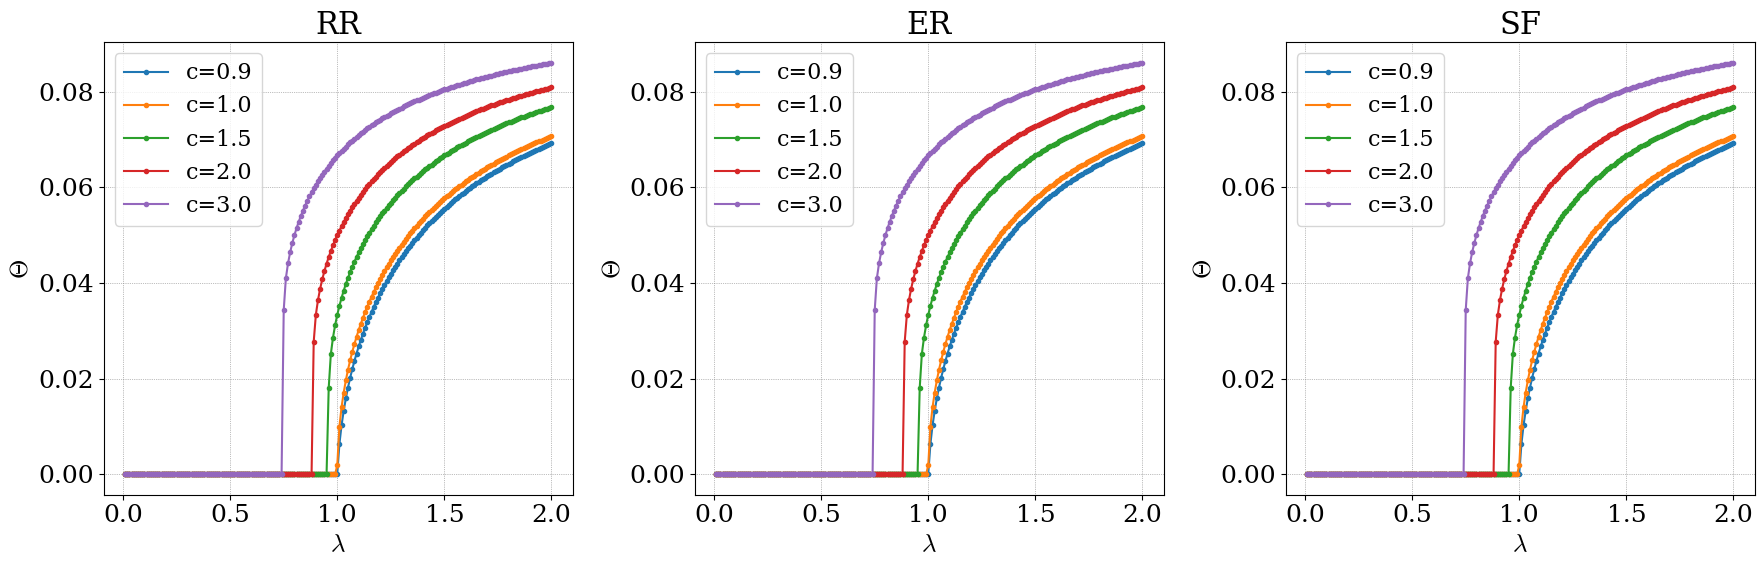

In [ ]:
# パラメータ設定
k_ave = 10        # 平均次数
gamma = 1.0       # 回復率

# 試行するlambdaの範囲
dlamb = 0.01
lambda_values = np.arange(dlamb, 2.0 + dlamb, dlamb) # 0より大きい値から開始
c_list = np.array([0.0, 0.5, 1.0, 1.5, 3.0])
kappa = 2.5 # 冪分布の指数

network_type_list = ["RR", "ER", "SF"]
fig, axes = plt.subplots(1, len(network_type_list), figsize=(len(network_type_list) * 6, 6))

for nidx, network_type in enumerate(network_type_list):
    for cidx, c in enumerate(c_list):
        theta_results = []

        # 各lambdaについてニュートン法でThetaを解く
        for lamb in lambda_values:
            if network_type == "RR":
                # 次数のリスト
                deg_list = [k_ave]
                pk = np.array([1.0])

            elif network_type == "ER":
                # 次数のリスト (ポアソン分布が意味を持つ範囲)
                # 平均の3倍+10程度あれば十分
                deg_list = np.arange(0, int(k_ave * 3) + 10)

                # 次数分布 p(k) を計算 (ポアソン分布)
                pk = scipy.stats.poisson.pmf(deg_list, k_ave)
                print(pk)

            elif network_type == "SF":
                deg_list = np.arange(1, 1000)

                C = (2 - kappa) * k_ave
                pk = C * deg_list ** (- kappa)

            else:
                raise ValueError(f"Invalid network type: {network_type}")

            # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
            # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
            solution = newton_method(deg_list, pk, lamb, gamma, Theta_initial=1.0, c=c)
            
            # 物理的に意味のある解は Theta >= 0
            if solution < 0:
                solution = 0
                
            theta_results.append(solution)
            # print(f"{lamb:.4f}, {solution:.8f}")

        # 結果をプロット
        axes[nidx].plot(lambda_values, theta_results, marker='.', linestyle='-', color=colors[cidx], label=rf'c={c}')
    axes[nidx].set_xlabel(r'$\lambda$')
    axes[nidx].set_ylabel(r'$\Theta$')
    title = f'{network_type}' if network_type != "SF" else f'{network_type} (kappa={kappa})'
    axes[nidx].set_title(title)
    axes[nidx].grid(True)
    axes[nidx].legend(loc='best')

fig.tight_layout()
plt.show()

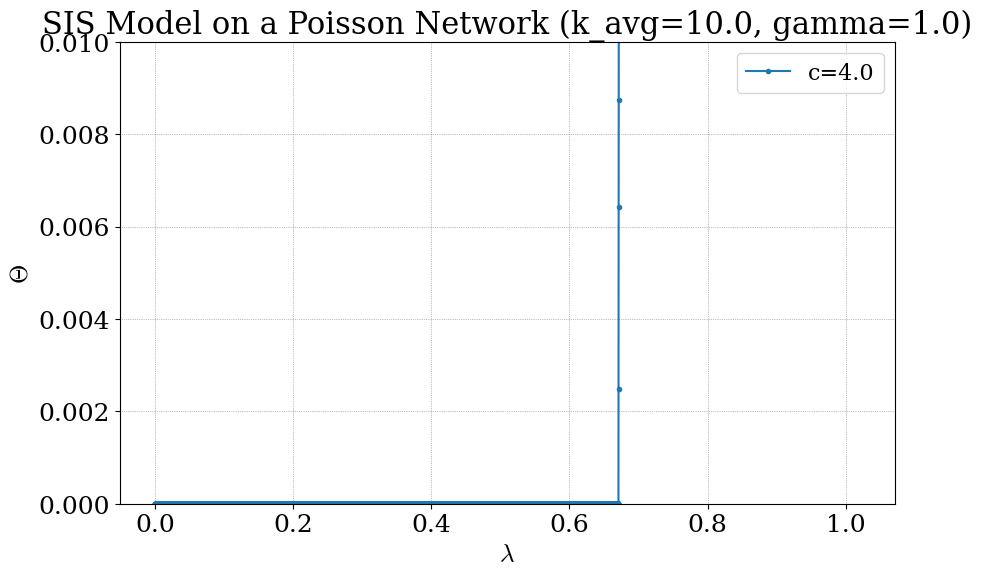

In [34]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0

    dy = 0
    for k, p in zip(deg_list, pk):
        denominator = (gamma + lamb * k * Theta)
        if denominator == 0: # ゼロ除算を避ける
            return np.nan # 計算不能
        dy += k * p * (lamb * gamma) / (denominator ** 2)
        
    dy /= k_ave
    dy -= 1
    return dy

# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.5, tolerance=1e-8, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta


# --- メインの実行部分 ---
if __name__ == '__main__':
    # パラメータ設定
    k_ave = 10.0      # 平均次数
    gamma = 1.0       # 回復率
    
    # 次数のリスト (ポアソン分布が意味を持つ範囲)
    # 平均の3倍+10程度あれば十分
    deg_list = np.arange(0, int(k_ave * 3) + 10)
    
    # 次数分布 p(k) を計算 (ポアソン分布)
    # pk = scipy.stats.poisson.pmf(deg_list, k_ave)
    # print(pk)

    pk = np.ones(len(deg_list)) / len(deg_list)

    # 冪分布 p(k) = Ck^(-kappa)
    # pk = deg_list ** (-2.5)

    # 試行するlambdaの範囲
    dlamb = 0.0001
    lambda_values = np.arange(dlamb, 1.02, dlamb) # 0より大きい値から開始

    theta_results = []
    c_list = np.array([4.0])
    plt.figure(figsize=(10, 6))

    for cidx, c in enumerate(c_list):
        theta_results = []
    # 各lambdaについてニュートン法でThetaを解く
        for lamb in lambda_values:
            # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
            # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
            solution = newton_method(deg_list, pk, lamb, gamma, Theta_initial=1.0, c=c)
            
            # 物理的に意味のある解は Theta >= 0
            if solution < 0:
                solution = 0
                
            theta_results.append(solution)
            # print(f"{lamb:.4f}, {solution:.8f}")

        # 結果をプロット
        plt.plot(lambda_values, theta_results, marker='.', linestyle='-', color=colors[cidx], label=rf'c={c}')
    plt.xlabel(r'$\lambda$')
    plt.ylabel(r'$\Theta$')
    plt.title(f'SIS Model on a Poisson Network (k_avg={k_ave}, gamma={gamma})')
    plt.grid(True)
    plt.ylim(0, 0.01)
    plt.legend()
    plt.show()